# LAB 1: Regression 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

### ขั้นตอนที่ 1: Load Dataset และเลือกเฉพาะ DC

In [13]:
df = pd.read_csv('comic_characters.csv')
print("จำนวนข้อมูลทั้งหมด:", df.shape)

dc = df[df['Universe'] == 'DC'].copy()
print("จำนวนข้อมูลเฉพาะ DC:", dc.shape)
dc.head()

จำนวนข้อมูลทั้งหมด: (21144, 12)
จำนวนข้อมูลเฉพาะ DC: (6479, 12)


,Id,Name,Identity,Alignment,Eyes,Hair,Sex,Alive,Appearances,First_appeared,Planet,Universe
2,2,John Malone,Secret,Bad,Blue,White,Male,Yes,15,"1985, January",New Earth,DC
3,3,"Samuel Bradley, Jr.",Public,Bad,Brown,Brown,Male,No,19,"2004, March",New Earth,DC
4,4,Hope Taya,Public,Bad,Brown,Black,Female,Yes,28,"1999, December",New Earth,DC
5,5,Trygg,Secret,Bad,Black,Black,Male,Yes,3,"1940, June",New Earth,DC
6,6,Boris Dmitravich Razumihin,Public,Good,Brown,Black,Male,Yes,7,"1987, December",New Earth,DC


In [19]:
print(dc.info())
print("\nจำนวนค่าว่างในแต่ละคอลัมน์:")
print(dc.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6479 entries, 0 to 6478
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              6479 non-null   int64  
 1   Name            6479 non-null   str    
 2   Identity        6479 non-null   str    
 3   Alignment       6479 non-null   str    
 4   Eyes            6479 non-null   str    
 5   Hair            6479 non-null   str    
 6   Sex             6479 non-null   str    
 7   Alive           6479 non-null   str    
 8   Appearances     6479 non-null   int64  
 9   First_appeared  6479 non-null   str    
 10  Planet          6479 non-null   str    
 11  Universe        6479 non-null   str    
 12  Year            6479 non-null   float64
 13  Character_Age   6479 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 708.8 KB
None

จำนวนค่าว่างในแต่ละคอลัมน์:
Id                0
Name              0
Identity          0
Alignment         0
Eyes     

### ขั้นตอนที่ 2: Feature Engineering — สร้าง Character_Age

In [14]:
dc['Year'] = dc['First_appeared'].str.extract(r'(\d{4})').astype(float)
dc = dc.dropna(subset=['Year']).reset_index(drop=True)

REFERENCE_YEAR = int(dc['Year'].max())
dc['Character_Age'] = REFERENCE_YEAR - dc['Year']

print("ปีอ้างอิง (Reference Year):", REFERENCE_YEAR)
dc[['Name', 'First_appeared', 'Year', 'Character_Age', 'Appearances']].head()

ปีอ้างอิง (Reference Year): 2013


,Name,First_appeared,Year,Character_Age,Appearances
0,John Malone,"1985, January",1985.0,28.0,15
1,"Samuel Bradley, Jr.","2004, March",2004.0,9.0,19
2,Hope Taya,"1999, December",1999.0,14.0,28
3,Trygg,"1940, June",1940.0,73.0,3
4,Boris Dmitravich Razumihin,"1987, December",1987.0,26.0,7


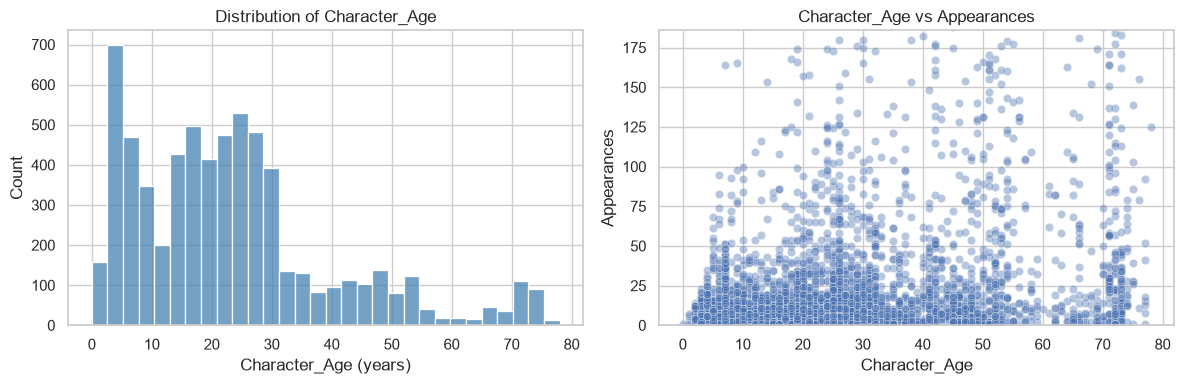

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(dc['Character_Age'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Character_Age')
axes[0].set_xlabel('Character_Age (years)')

sns.scatterplot(data=dc, x='Character_Age', y='Appearances', alpha=0.4, ax=axes[1])
axes[1].set_title('Character_Age vs Appearances')
axes[1].set_ylim(0, dc['Appearances'].quantile(0.98))

plt.tight_layout()
plt.show()

# Simple Linear Regression

In [15]:
X = dc[['Character_Age']]
y = dc['Appearances']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

y_pred_simple = simple_lr.predict(X_test)

print(f"สมการที่ได้: Appearances = {simple_lr.coef_[0]:.4f} * Character_Age + {simple_lr.intercept_:.4f}")

สมการที่ได้: Appearances = 1.3784 * Character_Age + -7.9396


In [21]:
mse_simple = mean_squared_error(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print(f"MSE : {mse_simple:.2f}")
print(f"MAE : {mae_simple:.2f}")
print(f"R^2 : {r2_simple:.4f}")

MSE : 2979.08
MAE : 25.60
R^2 : 0.0586


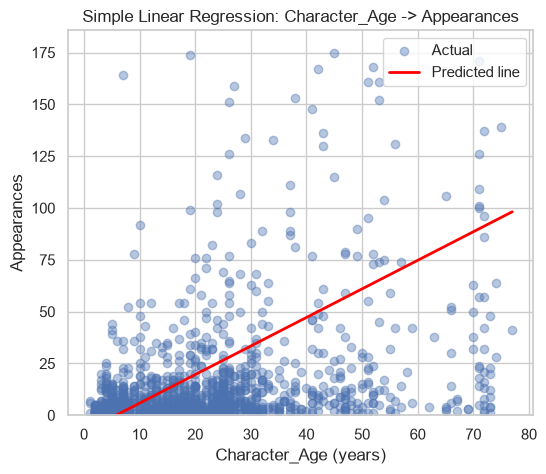

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(X_test, y_test, alpha=0.4, label='Actual')
order = np.argsort(X_test['Character_Age'].values)
plt.plot(X_test['Character_Age'].values[order], y_pred_simple[order], color='red', linewidth=2, label='Predicted line')
plt.ylim(0, y.quantile(0.98))
plt.xlabel('Character_Age (years)')
plt.ylabel('Appearances')
plt.title('Simple Linear Regression: Character_Age -> Appearances')
plt.legend(['Actual', 'Predicted line'])
plt.show()

# Multiple Linear Regression

In [16]:
cat_features = ['Alignment', 'Identity', 'Sex', 'Alive']
num_features = ['Character_Age']
features_multi = num_features + cat_features

X_multi = dc[features_multi]
y_multi = dc['Appearances']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
], remainder='passthrough')

multi_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])

Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
multi_pipeline.fit(Xm_train, ym_train)
y_pred_multi = multi_pipeline.predict(Xm_test)

In [23]:
mse_multi = mean_squared_error(ym_test, y_pred_multi)
mae_multi = mean_absolute_error(ym_test, y_pred_multi)
r2_multi = r2_score(ym_test, y_pred_multi)

comparison = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MSE': [mse_simple, mse_multi],
    'MAE': [mae_simple, mae_multi],
    'R2': [r2_simple, r2_multi]
})
comparison

,Model,MSE,MAE,R2
0,Simple Linear Regression,2979.075436,25.602076,0.058595
1,Multiple Linear Regression,2920.922250,26.426481,0.076971


# Age Prediction

In [17]:
features_age = ['Appearances'] + cat_features
X_age = dc[features_age]
y_age = dc['Character_Age']

preprocess_age = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
], remainder='passthrough')

age_pipeline = Pipeline([
    ('preprocess', preprocess_age),
    ('regressor', LinearRegression())
])

Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_age, y_age, test_size=0.2, random_state=42)
age_pipeline.fit(Xa_train, ya_train)
y_pred_age = age_pipeline.predict(Xa_test)

mse_age = mean_squared_error(ya_test, y_pred_age)
mae_age = mean_absolute_error(ya_test, y_pred_age)
r2_age = r2_score(ya_test, y_pred_age)

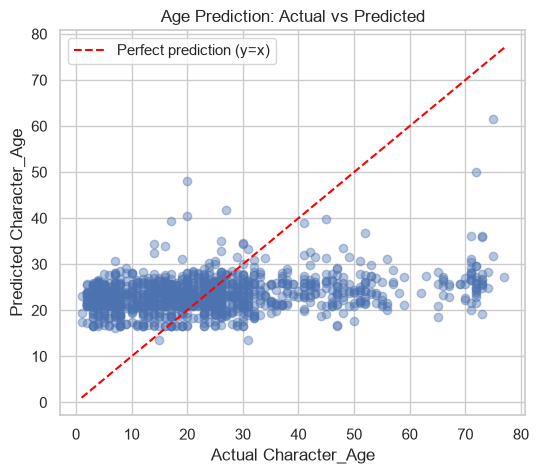

In [24]:
plt.figure(figsize=(6, 5))
plt.scatter(ya_test, y_pred_age, alpha=0.4)
lims = [ya_test.min(), ya_test.max()]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction (y=x)')
plt.xlabel('Actual Character_Age')
plt.ylabel('Predicted Character_Age')
plt.title('Age Prediction: Actual vs Predicted')
plt.legend()
plt.show()

# LAB 2: Classification 

# Preparing Classification Data  

โค้ดส่วนนี้ทำหน้าที่: โหลดข้อมูล → กรองเฉพาะเพศ Male/Female → แปลงคอลัมน์ข้อความ (Alignment, Eyes, Hair ฯลฯ) เป็นตัวเลขด้วย LabelEncoder → ดึงปีจาก First_appeared → แบ่ง Train/Test → ปรับสเกลข้อมูลด้วย StandardScale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, roc_curve, roc_auc_score)

df = pd.read_csv('comic_characters.csv')

df = df[df['Sex'].isin(['Male', 'Female'])].copy()

df['Year'] = df['First_appeared'].str.extract(r'(\d{4})').astype(float)
df['Year'] = df['Year'].fillna(df['Year'].median())

cat_cols = ['Identity', 'Alignment', 'Eyes', 'Hair', 'Alive', 'Planet', 'Universe']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

target_le = LabelEncoder()
df['Sex_enc'] = target_le.fit_transform(df['Sex'])

feature_cols = [c + '_enc' for c in cat_cols] + ['Appearances', 'Year']
X = df[feature_cols]
y = df['Sex_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("จำนวนข้อมูล Train:", X_train.shape, " Test:", X_test.shape)
print(df['Sex'].value_counts())

จำนวนข้อมูล Train: (16212, 9)  Test: (4053, 9)
Sex
Male      14964
Female     5301
Name: count, dtype: int64


# Decision Boundary Visualization  

เลือก 2 ฟีเจอร์ที่เป็นตัวเลข (Appearances, Year) มาเทรนโมเดลแยกต่างหาก เพื่อวาดกราฟ 2 มิติแสดงขอบเขตการตัดสินใจ (decision boundary) ของโมเดลได้

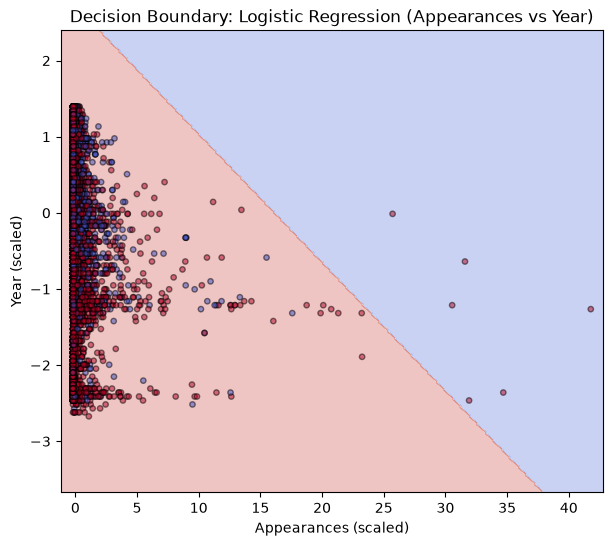

In [ ]:
X_vis = df[['Appearances', 'Year']].values
y_vis = df['Sex_enc'].values

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

model_vis = LogisticRegression()
model_vis.fit(X_vis_scaled, y_vis)

x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')         
plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis,  
            cmap='coolwarm', edgecolor='k', alpha=0.5, s=15)
plt.xlabel('Appearances (scaled)')
plt.ylabel('Year (scaled)')
plt.title('Decision Boundary: Logistic Regression (Appearances vs Year)')
plt.savefig('decision_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

# Logistic Regression

เทรนโมเดลหลักด้วยฟีเจอร์ทั้งหมดที่เตรียมไว้ในข้อ 1 (ใช้ข้อมูลที่ scale แล้ว)

In [3]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

print("ค่าสัมประสิทธิ์ (coefficient) ของแต่ละฟีเจอร์:")
for col, coef in zip(feature_cols, log_model.coef_[0]):
    print(f"  {col}: {coef:.4f}")

ค่าสัมประสิทธิ์ (coefficient) ของแต่ละฟีเจอร์:
  Identity_enc: 0.0243
  Alignment_enc: -0.2697
  Eyes_enc: 0.0843
  Hair_enc: -0.0182
  Alive_enc: -0.1004
  Planet_enc: 0.1022
  Universe_enc: 0.1838
  Appearances: -0.0373
  Year: -0.3722


# Gender Prediction

ใช้โมเดลที่เทรนแล้วทำนายเพศบนชุดทดสอบ และทดลองทำนายตัวละครตัวอย่าง

In [7]:
y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]   

sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
pred_label = target_le.inverse_transform(log_model.predict(sample_scaled))
pred_proba_sample = log_model.predict_proba(sample_scaled)[0]

print("ตัวอย่างพยากรณ์เพศของตัวละครตัวแรกในชุดทดสอบ:", pred_label[0])
print(f"ความน่าจะเป็น -> Female: {pred_proba_sample[0]:.3f}, Male: {pred_proba_sample[1]:.3f}")

ตัวอย่างพยากรณ์เพศของตัวละครตัวแรกในชุดทดสอบ: Male
ความน่าจะเป็น -> Female: 0.260, Male: 0.740


# Confusion Matrix

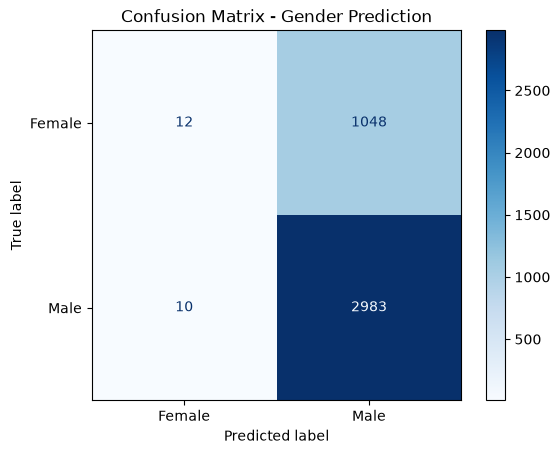

Confusion Matrix:
 [[  12 1048]
 [  10 2983]]


In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=target_le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Gender Prediction')
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print("Confusion Matrix:\n", cm)

# Simple vs Multiple Linear Regression

In [9]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42

df = pd.read_csv("comic_characters.csv")

def extract_year(text):
    try:
        return int(str(text).split(",")[0].strip())
    except Exception:
        return np.nan

df["Year"] = df["First_appeared"].apply(extract_year)
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)
df["Log_Appearances"] = np.log1p(df["Appearances"])

df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
y_train = df_train["Log_Appearances"]
y_test = df_test["Log_Appearances"]

X_train_simple = df_train[["Year"]]
X_test_simple = df_test[["Year"]]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)
pred_simple = simple_model.predict(X_test_simple)

r2_simple = r2_score(y_test, pred_simple)
rmse_simple = mean_squared_error(y_test, pred_simple) ** 0.5

print("[Simple Linear Regression] feature = Year")
print(f"  R^2 (test)  = {r2_simple:.4f}")
print(f"  RMSE (test) = {rmse_simple:.4f}")

numeric_features = ["Year"]
categorical_features = ["Alignment", "Sex", "Identity", "Universe", "Alive"]
feature_cols = numeric_features + categorical_features

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
multi_model = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])

multi_model.fit(df_train[feature_cols], y_train)
pred_multi = multi_model.predict(df_test[feature_cols])

r2_multi = r2_score(y_test, pred_multi)
rmse_multi = mean_squared_error(y_test, pred_multi) ** 0.5

print(f"\n[Multiple Linear Regression] features = {feature_cols}")
print(f"  R^2 (test)  = {r2_multi:.4f}")
print(f"  RMSE (test) = {rmse_multi:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(y_test, pred_simple, alpha=0.15, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title(f"Simple LR\nR2={r2_simple:.3f}")

axes[1].scatter(y_test, pred_multi, alpha=0.15, s=10, color="orange")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title(f"Multiple LR\nR2={r2_multi:.3f}")

plt.tight_layout()
plt.savefig("part1_simple_vs_multiple.png")

[Simple Linear Regression] feature = Year
  R^2 (test)  = 0.0101
  RMSE (test) = 1.1956

[Multiple Linear Regression] features = ['Year', 'Alignment', 'Sex', 'Identity', 'Universe', 'Alive']
  R^2 (test)  = 0.1003
  RMSE (test) = 1.1399


# Training vs Testing Performance

In [11]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

df = pd.read_csv("comic_characters.csv")

def extract_year(text):
    try:
        return int(str(text).split(",")[0].strip())
    except Exception:
        return np.nan

df["Year"] = df["First_appeared"].apply(extract_year)
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)
df["Log_Appearances"] = np.log1p(df["Appearances"])

df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
y_train = df_train["Log_Appearances"]
y_test = df_test["Log_Appearances"]

numeric_features = ["Year"]
categorical_features = ["Alignment", "Sex", "Identity", "Universe", "Alive"]
feature_cols = numeric_features + categorical_features

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
model = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
model.fit(df_train[feature_cols], y_train)

pred_train = model.predict(df_train[feature_cols])
pred_test = model.predict(df_test[feature_cols])

r2_train = r2_score(y_train, pred_train)
rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
mae_train = mean_absolute_error(y_train, pred_train)

r2_test = r2_score(y_test, pred_test)
rmse_test = mean_squared_error(y_test, pred_test) ** 0.5
mae_test = mean_absolute_error(y_test, pred_test)

print(f"{'Metric':<10}{'Train':>12}{'Test':>12}")
print(f"{'R^2':<10}{r2_train:>12.4f}{r2_test:>12.4f}")
print(f"{'RMSE':<10}{rmse_train:>12.4f}{rmse_test:>12.4f}")
print(f"{'MAE':<10}{mae_train:>12.4f}{mae_test:>12.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(["Train", "Test"], [r2_train, r2_test], color=["#4C72B0", "#DD8452"])
axes[0].set_title("R^2: Train vs Test")

axes[1].bar(["Train", "Test"], [rmse_train, rmse_test], color=["#4C72B0", "#DD8452"])
axes[1].set_title("RMSE: Train vs Test")

plt.tight_layout()
plt.savefig("part2_train_vs_test.png")

Metric           Train        Test
R^2             0.1022      0.1003
RMSE            1.1027      1.1399
MAE             0.8570      0.8777


# Regression vs Classification

In [10]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, RocCurveDisplay, roc_auc_score
)

RANDOM_STATE = 42

df = pd.read_csv("comic_characters.csv")

def extract_year(text):
    try:
        return int(str(text).split(",")[0].strip())
    except Exception:
        return np.nan

df["Year"] = df["First_appeared"].apply(extract_year)
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

df["Log_Appearances"] = np.log1p(df["Appearances"])   # target สำหรับ Regression
df["Alive_bin"] = (df["Alive"] == "Yes").astype(int)   # target สำหรับ Classification

df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

reg_features = ["Year", "Alignment", "Sex", "Identity", "Universe"]
y_train_reg = df_train["Log_Appearances"]
y_test_reg = df_test["Log_Appearances"]

preprocessor_reg = ColumnTransformer(transformers=[
    ("num", StandardScaler(), ["Year"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"),
     ["Alignment", "Sex", "Identity", "Universe"]),
])
reg_model = Pipeline([("prep", preprocessor_reg), ("reg", LinearRegression())])
reg_model.fit(df_train[reg_features], y_train_reg)
pred_reg = reg_model.predict(df_test[reg_features])

r2_reg = r2_score(y_test_reg, pred_reg)
rmse_reg = mean_squared_error(y_test_reg, pred_reg) ** 0.5

print("[Regression] R^2 =", round(r2_reg, 4), " RMSE =", round(rmse_reg, 4))

clf_features = ["Year", "Alignment", "Sex", "Identity", "Universe", "Appearances"]
y_train_clf = df_train["Alive_bin"]
y_test_clf = df_test["Alive_bin"]

preprocessor_clf = ColumnTransformer(transformers=[
    ("num", StandardScaler(), ["Year", "Appearances"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"),
     ["Alignment", "Sex", "Identity", "Universe"]),
])
clf_model = Pipeline([
    ("prep", preprocessor_clf),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
clf_model.fit(df_train[clf_features], y_train_clf)
pred_clf = clf_model.predict(df_test[clf_features])
pred_proba = clf_model.predict_proba(df_test[clf_features])[:, 1]

acc = accuracy_score(y_test_clf, pred_clf)
prec = precision_score(y_test_clf, pred_clf)
rec = recall_score(y_test_clf, pred_clf)
f1 = f1_score(y_test_clf, pred_clf)
auc = roc_auc_score(y_test_clf, pred_proba)
cm = confusion_matrix(y_test_clf, pred_clf)

print(f"[Classification] Accuracy={acc:.4f} Precision={prec:.4f} Recall={rec:.4f} F1={f1:.4f} AUC={auc:.4f}")
print("Confusion Matrix:\n", cm)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["No", "Yes"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center")

RocCurveDisplay.from_predictions(y_test_clf, pred_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve (AUC={auc:.3f})")

plt.tight_layout()
plt.savefig("part3_regression_vs_classification.png")

[Regression] R^2 = 0.1007  RMSE = 1.1396
[Classification] Accuracy=0.5306 Precision=0.7718 Recall=0.5271 F1=0.6264 AUC=0.5642
Confusion Matrix:
 [[ 580  492]
 [1493 1664]]
